# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import os
import sys
import subprocess
import pandas as pd
import numpy as np

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
            check=True
        )

    os.chdir(REPO_DIR)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
        check=True
    )
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found. Add your Hugging Face READ token "
        "as a Colab Secret named HF_TOKEN."
    )

print("HF_TOKEN found.")

import duckdb

con = duckdb.connect()

con.execute(
    "CREATE SECRET (TYPE huggingface, TOKEN ?)",
    [HF_TOKEN]
)

print("DuckDB connected to Hugging Face.")

march_df = con.sql("""
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        client_has_gsc,
        client_has_ga4,
        gsc_data_available,
        ga4_data_available,
        gsc_impressions,
        gsc_clicks,
        gsc_sum_position,
        scroll_events,
        sessions_ai,
        sessions_paid,
        sessions_direct,
        sessions_social,
        sessions_organic,
        month
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-03'
""").df()

print("March 2026 shape:", march_df.shape)
print(
    "Date range:",
    march_df["report_date"].min(),
    "to",
    march_df["report_date"].max()
)

display(march_df.head())

HF_TOKEN found.
DuckDB connected to Hugging Face.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March 2026 shape: (9841378, 17)
Date range: 2026-03-01 00:00:00 to 2026-03-31 00:00:00


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,scroll_events,sessions_ai,sessions_paid,sessions_direct,sessions_social,sessions_organic,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The playbook turns the validated Week-5 engagement model into a ranked human-review queue.

The model estimates observed `scroll_events` from search visibility and organic-session signals. A low predicted engagement level is treated as a directional review signal: the page may deserve investigation when it already has search visibility but shows weaker expected engagement.

The score is therefore a prioritization aid, not an automatic instruction to change content.

Reason codes make each recommendation understandable:

- HIGH_VISIBILITY_LOW_ENGAGEMENT — strong search visibility with comparatively weak predicted engagement.
- HIGH_VISIBILITY_CTR_REVIEW — substantial impressions but comparatively weak click-through signal.
- POSITION_REVIEW — search position suggests an opportunity for review.
- MIXED_SIGNAL_REVIEW — signals do not point to one clear action.

The final action is always "Human review" before any content change.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import rankdata

model_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_sum_position",
    "sessions_organic",
    "scroll_events"
]

model_df = march_df[
    [
        "report_date",
        "client_hash_id",
        "content_hash_id"
    ] + model_cols
].copy()

for col in model_cols:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

model_df = model_df.dropna(
    subset=[
        "gsc_impressions",
        "gsc_clicks",
        "gsc_sum_position",
        "scroll_events"
    ]
).copy()

feature_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_sum_position",
    "sessions_organic"
]

X = model_df[feature_cols].copy()
y = model_df["scroll_events"].copy()
groups = model_df["client_hash_id"].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

group_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

group_model.fit(X_train, y_train)

test_pred = group_model.predict(X_test)

print("Grouped-client model trained.")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Test clients:", groups.iloc[test_idx].nunique())

Grouped-client model trained.
Training rows: 4879304
Test rows: 1943333
Test clients: 9


In [4]:
queue = model_df.iloc[test_idx].copy()

queue["predicted_scroll_events"] = test_pred

# Higher opportunity = lower predicted engagement
queue["engagement_opportunity"] = (
    1 - queue["predicted_scroll_events"].rank(pct=True)
)

queue["impression_rank"] = (
    queue["gsc_impressions"].rank(pct=True)
)

queue["click_rank"] = (
    queue["gsc_clicks"].rank(pct=True)
)

queue["position_rank"] = (
    1 - queue["gsc_sum_position"].rank(pct=True)
)

queue["action_score"] = (
    0.50 * queue["engagement_opportunity"]
    + 0.30 * queue["impression_rank"]
    + 0.20 * queue["position_rank"]
)

print("Action score created.")
display(
    queue[
        [
            "content_hash_id",
            "action_score",
            "predicted_scroll_events",
            "gsc_impressions",
            "gsc_clicks",
            "gsc_sum_position"
        ]
    ].head()
)

Action score created.


,content_hash_id,action_score,predicted_scroll_events,gsc_impressions,gsc_clicks,gsc_sum_position
20000,content_3dd7e9bdc07d4176,0.571344,0.003686,0,0,0
20001,content_bbb4aa7e6bc7d44d,0.571344,0.003686,0,0,0
20002,content_87d0432b98cb9c6a,0.571344,0.003686,0,0,0
20003,content_a96405dce841f892,0.571344,0.003686,0,0,0
20004,content_a6319ba74471df14,0.571344,0.003686,0,0,0


In [5]:
impression_cutoff = queue["gsc_impressions"].quantile(0.75)
click_rate = (
    queue["gsc_clicks"]
    / queue["gsc_impressions"].replace(0, np.nan)
)

ctr_cutoff = click_rate.quantile(0.25)
position_cutoff = queue["gsc_sum_position"].quantile(0.75)
opportunity_cutoff = queue["engagement_opportunity"].quantile(0.75)

queue["ctr_proxy"] = click_rate

queue["reason_code"] = np.select(
    [
        (
            (queue["gsc_impressions"] >= impression_cutoff)
            & (
                queue["engagement_opportunity"]
                >= opportunity_cutoff
            )
        ),

        (
            (queue["gsc_impressions"] >= impression_cutoff)
            & (queue["ctr_proxy"] <= ctr_cutoff)
        ),

        (
            queue["gsc_sum_position"] >= position_cutoff
        )
    ],
    [
        "HIGH_VISIBILITY_LOW_ENGAGEMENT",
        "HIGH_VISIBILITY_CTR_REVIEW",
        "POSITION_REVIEW"
    ],
    default="MIXED_SIGNAL_REVIEW"
)

queue["action"] = "Human review"

queue = queue.sort_values(
    [
        "action_score",
        "gsc_impressions",
        "gsc_clicks"
    ],
    ascending=[False, False, False]
).reset_index(drop=True)

queue["rank"] = np.arange(
    1,
    len(queue) + 1
)

queue_cols = [
    "rank",
    "report_date",
    "client_hash_id",
    "content_hash_id",
    "action_score",
    "reason_code",
    "action",
    "predicted_scroll_events",
    "gsc_impressions",
    "gsc_clicks",
    "ctr_proxy",
    "gsc_sum_position",
    "sessions_organic"
]

ranked_queue = queue[queue_cols].copy()

display(ranked_queue.head(20))

,rank,report_date,client_hash_id,content_hash_id,action_score,reason_code,action,predicted_scroll_events,gsc_impressions,gsc_clicks,ctr_proxy,gsc_sum_position,sessions_organic
0,1,2026-03-14,client_e547b89c05043229,content_85fbeb8bf5fbb90e,0.586471,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.013856,255,0,0.000000,0,0
1,2,2026-03-04,client_e547b89c05043229,content_7888373b5884ed2b,0.583450,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.013856,208,0,0.000000,0,0
2,3,2026-03-15,client_e547b89c05043229,content_85fbeb8bf5fbb90e,0.582744,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.013856,199,0,0.000000,0,0
3,4,2026-03-30,client_e547b89c05043229,content_c595149977a96d84,0.582202,MIXED_SIGNAL_REVIEW,Human review,0.014178,201,1,0.004975,0,0
4,5,2026-03-08,client_23a62021009f63c4,content_a13c0af1132f0581,0.574345,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.015151,142,0,0.000000,0,0
5,6,2026-03-15,client_e547b89c05043229,content_007c73f1f29fb2ef,0.573610,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.015228,139,0,0.000000,0,0
6,7,2026-03-17,client_e547b89c05043229,content_ad51e400b57b772c,0.573316,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.015228,137,0,0.000000,0,0
7,8,2026-03-09,client_e547b89c05043229,content_1ca179a517fc24e6,0.573141,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.015158,134,0,0.000000,0,0
8,9,2026-03-10,client_e547b89c05043229,content_3d7b7011738d682f,0.573125,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.014944,131,0,0.000000,0,0
9,10,2026-03-13,client_e547b89c05043229,content_f9e04ee043a37ad6,0.572792,HIGH_VISIBILITY_CTR_REVIEW,Human review,0.014742,127,0,0.000000,0,0


### Archetype → action mapping

| Archetype | Meaning | Human action |
|---|---|---|
| High visibility + low predicted engagement | Search demand exists but observed engagement signal is weaker | Review title, snippet, intent match, opening content, and UX |
| High visibility + weak CTR proxy | Impressions are present but clicks are relatively weak | Review SERP title/meta positioning and search intent match |
| Position review | Search position signal is comparatively weaker | Review relevance, content depth, internal linking, and topical coverage |
| Mixed signal | No single signal dominates | Manual inspection before choosing an action |

The mapping is intentionally advisory. The model does not publish, delete, rewrite, or refresh content automatically.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is designed for a content strategist, SEO analyst, or researcher to decide which anonymized content items deserve human review first.

The ranked queue helps reduce the search space. It does not decide the final content action.

### What the score means

The score is a directional prioritization score built from a validated model and observed March 2026 warehouse signals.

It should be interpreted as:

> "This item is relatively higher in the review queue under the current model and data."

It should not be interpreted as:

> "Refreshing this page will definitely improve performance."

### Limits

- The model was evaluated on a March 2026 development slice.
- The validation target is observed `scroll_events`.
- The model does not establish causality.
- The score does not prove that refreshing a page will increase traffic, clicks, or conversions.
- Client-level grouped validation reduces repeated-client leakage risk, but it does not make the result universally generalizable.
- Missing GSC or GA4 data can represent source unavailability rather than zero performance.
- The warehouse is anonymized and should remain outside the repository.
- Human review is required before any content change.

### Refresh/decay insight

Content freshness can be a useful review consideration, but this model does not directly estimate content age or time since last refresh because those variables are not part of the validated Week-5 feature set.

Therefore, freshness is a human-review question rather than a model-generated fact in this playbook.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review checklist

Before taking any content action, a reviewer should check:

1. Is the page relevant to the intended search intent?
2. Is the page already being actively updated?
3. Are the GSC signals complete and available for this client?
4. Is the recommendation driven by one unusual metric or several consistent signals?
5. Does the page have business or user importance that is not represented in the model?
6. Would changing the page risk removing useful information?
7. Is there a clear, evidence-based content change to test?
8. Can the change be evaluated after implementation?

### What should NOT be automated

The model must not automatically:

- publish content;
- delete content;
- rewrite titles or body copy;
- change URLs;
- redirect pages;
- remove pages from an index;
- make client-facing claims;
- decide that a page is "bad";
- infer business value that is not present in the data;
- claim that an action caused a traffic or ranking improvement.

The model only prioritizes items for human review.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

human_review_rules = pd.DataFrame({
    "check": [
        "Search intent relevance",
        "Data availability",
        "Multiple-signal confirmation",
        "Business/user importance",
        "Risk of content change",
        "Clear testable action",
        "Post-change evaluation"
    ],
    "required_before_action": [True] * 7
})

no_go_automation = [
    "Automatic publishing",
    "Automatic deletion",
    "Automatic rewriting",
    "Automatic URL changes",
    "Automatic redirects",
    "Automatic indexing decisions",
    "Automatic client-facing claims"
]

print("Human review rules:")
display(human_review_rules)

print("\nNo-go automation list:")
for item in no_go_automation:
    print("-", item)

Human review rules:


,check,required_before_action
0,Search intent relevance,True
1,Data availability,True
2,Multiple-signal confirmation,True
3,Business/user importance,True
4,Risk of content change,True
5,Clear testable action,True
6,Post-change evaluation,True



No-go automation list:
- Automatic publishing
- Automatic deletion
- Automatic rewriting
- Automatic URL changes
- Automatic redirects
- Automatic indexing decisions
- Automatic client-facing claims


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The queue should be treated as stale when the data distribution or validation performance changes enough that the existing ranking may no longer represent the current environment.

### Monitoring checks

Monitor:

- feature missingness;
- distribution of impressions, clicks, position, and organic sessions;
- distribution of predicted scores;
- grouped-client validation Spearman correlation;
- ranking stability;
- availability of GSC and GA4 data.

### Suggested retrain triggers

A model review/retrain should be considered when:

1. grouped-client Spearman performance falls materially relative to the validation receipt;
2. feature missingness changes materially;
3. the distribution of major features shifts substantially;
4. the source schema changes;
5. the available data window changes substantially;
6. a new validated label or outcome becomes available;
7. repeated human review shows that the queue frequently produces weak or irrelevant candidates.

These are review triggers, not automatic retraining commands.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

monitoring_snapshot = pd.DataFrame({
    "metric": [
        "Rows in current queue",
        "Unique clients",
        "Missing impressions",
        "Missing clicks",
        "Missing position",
        "Missing organic sessions",
        "Median impressions",
        "Median clicks",
        "Median position",
        "Median predicted scroll events"
    ],
    "value": [
        len(queue),
        queue["client_hash_id"].nunique(),
        queue["gsc_impressions"].isna().mean(),
        queue["gsc_clicks"].isna().mean(),
        queue["gsc_sum_position"].isna().mean(),
        queue["sessions_organic"].isna().mean(),
        queue["gsc_impressions"].median(),
        queue["gsc_clicks"].median(),
        queue["gsc_sum_position"].median(),
        queue["predicted_scroll_events"].median()
    ]
})

display(monitoring_snapshot)

,metric,value
0,Rows in current queue,1.943333e+06
1,Unique clients,9.000000e+00
2,Missing impressions,0.000000e+00
3,Missing clicks,0.000000e+00
4,Missing position,0.000000e+00
5,Missing organic sessions,0.000000e+00
6,Median impressions,0.000000e+00
7,Median clicks,0.000000e+00
8,Median position,0.000000e+00
9,Median predicted scroll events,3.685820e-03


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked queue is exported to `work/outputs/`.

The CSV is regenerated by the notebook and should remain out of Git according to the repository's data-handling design.

A compact metrics receipt is also generated so that the paper can trace the validation setup and queue size back to this notebook.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue_path = "work/outputs/action_playbook_queue.csv"

ranked_queue.to_csv(
    queue_path,
    index=False
)

print("Queue exported:")
print(queue_path)

print("Rows:", len(ranked_queue))
print("Top 20 rows:", min(20, len(ranked_queue)))

Queue exported:
work/outputs/action_playbook_queue.csv
Rows: 1943333
Top 20 rows: 20


In [10]:
from scipy.stats import spearmanr
import json

grouped_spearman = spearmanr(
    y_test,
    test_pred
).statistic

metrics_receipt = {
    "week": "ML-10",
    "model": "RandomForestRegressor",
    "target": "scroll_events",
    "data_window": "2026-03",
    "validation": "grouped_by_client",
    "random_state": 42,
    "n_estimators": 150,
    "max_depth": 10,
    "min_samples_leaf": 20,
    "test_rows": int(len(X_test)),
    "test_clients": int(groups.iloc[test_idx].nunique()),
    "grouped_spearman": float(grouped_spearman),
    "queue_rows": int(len(ranked_queue)),
    "queue_action": "Human review",
    "claim_type": "directional_decision_support"
}

metrics_path = "work/outputs/ml10_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )

print("Metrics receipt exported:")
print(metrics_path)

display(pd.DataFrame([metrics_receipt]))

Metrics receipt exported:
work/outputs/ml10_metrics.json


,week,model,target,data_window,validation,random_state,n_estimators,max_depth,min_samples_leaf,test_rows,test_clients,grouped_spearman,queue_rows,queue_action,claim_type
0,ML-10,RandomForestRegressor,scroll_events,2026-03,grouped_by_client,42,150,10,20,1943333,9,0.275906,1943333,Human review,directional_decision_support


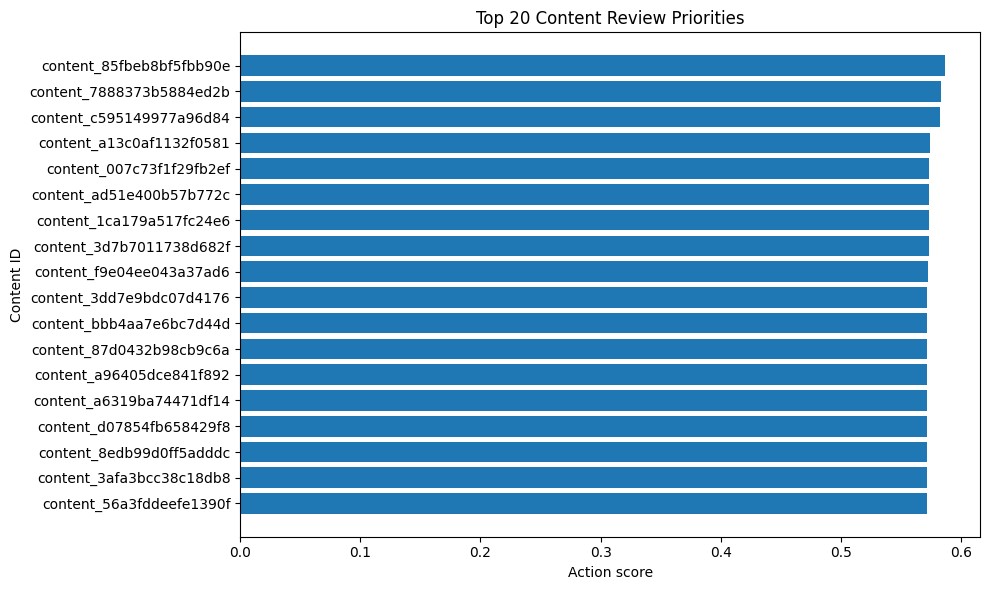

Figure saved:
work/figures/top20_action_priorities.png


In [11]:
import matplotlib.pyplot as plt

top20 = ranked_queue.head(20).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top20["content_hash_id"].astype(str),
    top20["action_score"]
)

plt.xlabel("Action score")
plt.ylabel("Content ID")
plt.title("Top 20 Content Review Priorities")

plt.gca().invert_yaxis()

plt.tight_layout()

figure_path = "work/figures/top20_action_priorities.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.